# Прогноз недельного спроса

## Задача

Построить модель, которая прогнозирует количество единиц каждого товара, проданных на следующей неделе. Прогноз может использоваться для планирования закупок и управления запасами.

## Данные

Датасет содержит транзакции интернет-магазина.

- `InvoiceNo` — номер заказа; заказы, начинающиеся с `C`, являются отменами.
- `StockCode` — код товара.
- `Description` — название товара.
- `Quantity` — количество единиц товара в заказе.
- `InvoiceDate` — дата и время оформления заказа.
- `UnitPrice` — цена одной единицы товара.
- `CustomerID` — идентификатор покупателя.
- `Country` — страна покупателя.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Загрузка таблицы

df = pd.read_excel("Online Retail.xlsx")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


## ОТЧИСТКА ДАННЫХ

In [3]:
# Смотрим из чего состоит таблица

df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [4]:
# Смотрим сколько NaN значений во всей таблице

df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
# Переводим колонку InvoiceDate в формат datetime

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [6]:
# Смотрим сколько уникальных значений в категориальной колонке Country

df['Country'].nunique()

38

In [7]:
# Отсортируем талицу по колонке InvoiceDate

df = df.sort_values("InvoiceDate").reset_index(drop=True)
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22555,PLASTERS IN TIN STRONGMAN,12,2011-12-09 12:50:00,1.65,12680.0,France
541905,581587,22556,PLASTERS IN TIN CIRCUS PARADE,12,2011-12-09 12:50:00,1.65,12680.0,France
541906,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,2011-12-09 12:50:00,3.75,12680.0,France


In [8]:
# В колонке InvoiceNo у нас все номера которые начинаются с 'C' это отмененные заказы, они нам не нужны
# посмотрим сколько у нас всего таких строк которые надо удалить 

df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9288)

In [9]:
# Удалим в df все строки которые начинаются с 'C' в колонке InvoiceNo

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [10]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22555,PLASTERS IN TIN STRONGMAN,12,2011-12-09 12:50:00,1.65,12680.0,France
541905,581587,22556,PLASTERS IN TIN CIRCUS PARADE,12,2011-12-09 12:50:00,1.65,12680.0,France
541906,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,2011-12-09 12:50:00,3.75,12680.0,France


In [11]:
# Смотрим сколько у нас количества единиц товара в заказе меньше или равно 0, чтобы далее удалить эти строки

df[df["Quantity"] <= 0]

# товар в заказе есть, а фактически ничего не продано. 
# Такие строки не несут информации о спросе.
# отрицательное количество. Это обычно следствие возвратов, 
# корректировок, списаний или технических операций в системе учёта. 
# Например, клиент вернул товар, и в базе появилась строка с минусом.

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4335,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535334,581210,23395,check,-26,2011-12-07 18:36:00,0.0,NaN,United Kingdom
535335,581213,22576,check,-30,2011-12-07 18:38:00,0.0,NaN,United Kingdom
535336,581212,22578,lost,-1050,2011-12-07 18:38:00,0.0,NaN,United Kingdom
536910,581226,23090,missing,-338,2011-12-08 09:56:00,0.0,NaN,United Kingdom


In [12]:
# Смотрим сколько у нас цена одной единицы товара меньше или равно 0, чтобы далее удалить эти строки

df[df["UnitPrice"] <= 0]

# UnitPrice = 0 — обычно это служебные операции: 
# бесплатные образцы, бонусы, исправления, накладные расходы, комиссии и т.п. 
# Это не настоящая продажа по рыночной цене.
# отрицательная цена, тоже аномалия: корректировки, возвраты денег, ошибки ввода.

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1655,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1979,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1985,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
2003,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
536969,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom
538504,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,NaN,United Kingdom
538505,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom
538554,581408,85175,NaN,20,2011-12-08 14:06:00,0.0,NaN,United Kingdom


In [13]:
# Удаляем строки с Quantity <= 0 и UnitPrice <= 0

df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536368,22914,BLUE COAT RACK PARIS FASHION,3,2010-12-01 08:34:00,4.95,13047.0,United Kingdom


In [14]:
# Проверяем дубликаты 

df.duplicated().sum()

np.int64(5226)

In [15]:
# Удаляем дубликаты

df = df.drop_duplicates()

In [16]:
# Проверяем остались ли дубликаты

df.duplicated().sum()

np.int64(0)

In [ ]:
# Проверяем где остались пропуски

df.isna().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
dtype: int64

In [18]:
# Удаляем CustomerID так как он не нужен для обучения модели и для EDA анализа

df = df.drop('CustomerID', axis=1)

In [ ]:
# Смотрим размер датасета после всех отчисток

df.shape

(524878, 7)

In [21]:
# Сбрасываем индекс после всех отчисток

df = df.reset_index(drop=True)

## EDA АНАЛИЗ

In [23]:
df['Quantity'].describe()

count    524878.000000
mean         10.616600
std         156.280031
min           1.000000
25%           1.000000
50%           4.000000
75%          11.000000
max       80995.000000
Name: Quantity, dtype: float64

In [27]:
df['UnitPrice'].describe()

count    524878.000000
mean          3.922573
std          36.093028
min           0.001000
25%           1.250000
50%           2.080000
75%           4.130000
max       13541.330000
Name: UnitPrice, dtype: float64

99-й перцентиль Quantity: 100.0


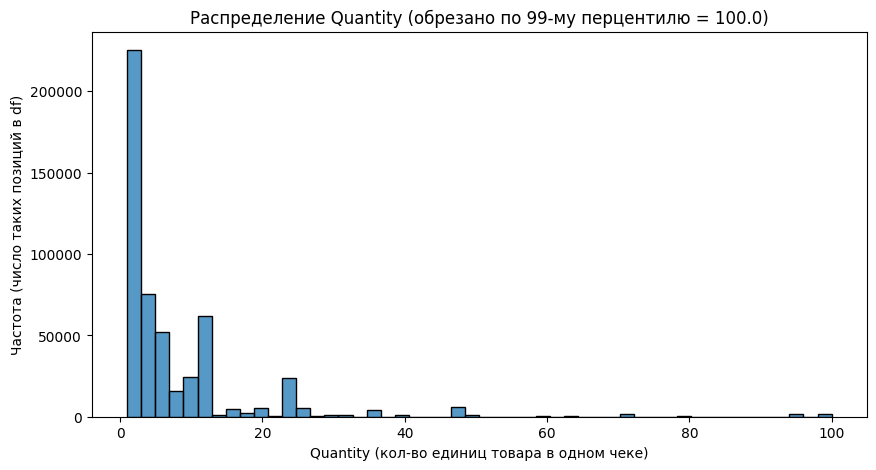

In [39]:
# Построим histogram для Quantity, ограничив график 99-м перцентилем, 
# чтобы экстремальные значения не скрыли основную картину.

q99_qty = df['Quantity'].quantile(0.99)
print(f"99-й перцентиль Quantity: {q99_qty}")

plt.figure(figsize=(10, 5))
sns.histplot(df.loc[df['Quantity'] <= q99_qty, 'Quantity'], bins=50)
plt.title(f'Распределение Quantity (обрезано по 99-му перцентилю = {q99_qty})')
plt.xlabel('Quantity (кол-во единиц товара в одном чеке)')
plt.ylabel('Частота (число таких позиций в df)')
plt.show()

99-й перцентиль UnitPrice: 16.98


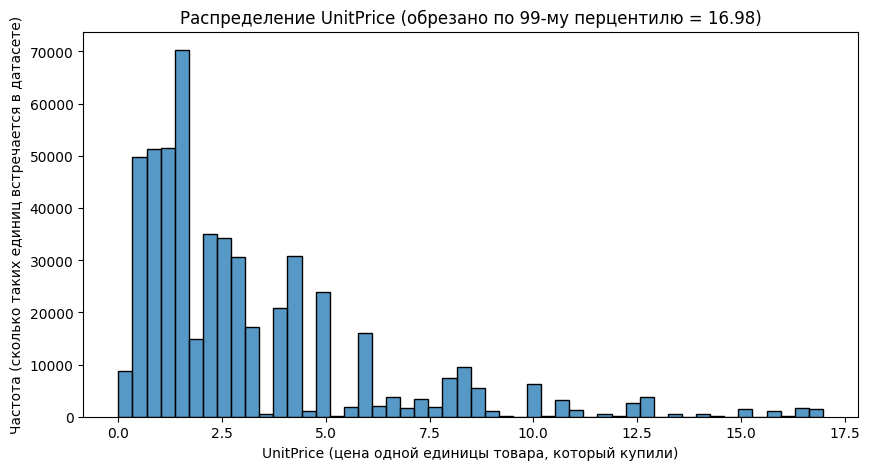

In [41]:
# Построим histogram для UnitPrice, ограничив график 99-м перцентилем, 
# чтобы экстремальные значения не скрыли основную картину.

q99_price = df['UnitPrice'].quantile(0.99)
print(f'99-й перцентиль UnitPrice: {q99_price}')

plt.figure(figsize=(10, 5))
sns.histplot(df.loc[df['UnitPrice'] <= q99_price, 'UnitPrice'], bins=50)
plt.title(f'Распределение UnitPrice (обрезано по 99-му перцентилю = {q99_price})')
plt.xlabel('UnitPrice (цена одной единицы товара, который купили)')
plt.ylabel('Частота (сколько таких единиц встречается в датасете)')
plt.show()

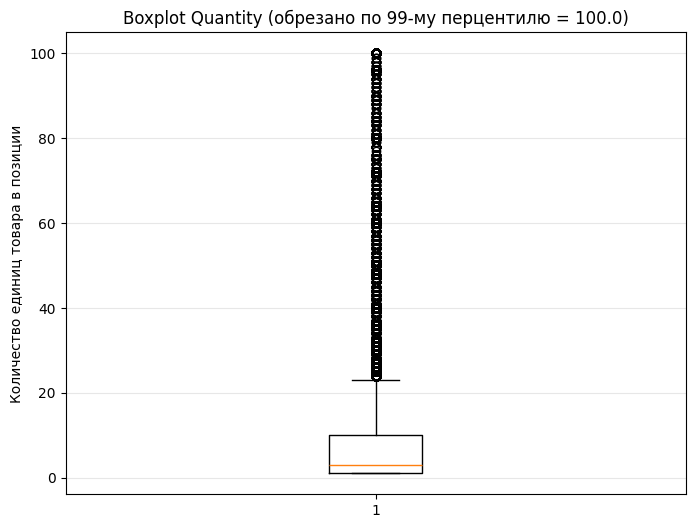

In [49]:
# Рисуем ящик с усами для Quantity

plt.figure(figsize=(8, 6))
plt.boxplot(df.loc[df['Quantity'] <= q99_qty, 'Quantity'].values)
plt.title(f'Boxplot Quantity (обрезано по 99-му перцентилю = {q99_qty})')
plt.ylabel('Количество единиц товара в позиции')
plt.grid(axis='y', alpha=0.3)
plt.show()

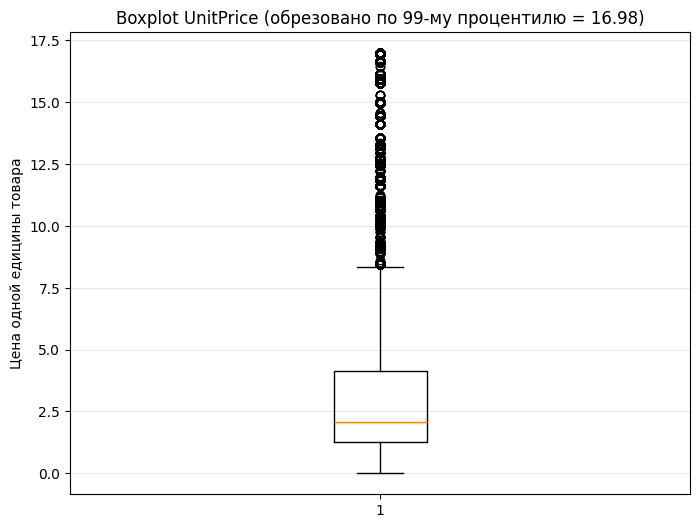

In [51]:
# Рисуем ящик с усами для UnitPcie

plt.figure(figsize=(8, 6))
plt.boxplot(df.loc[df['UnitPrice'] <= q99_price, 'UnitPrice'].values)
plt.title(f'Boxplot UnitPrice (обрезовано по 99-му процентилю = {q99_price})')
plt.ylabel('Цена одной едицины товара')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [61]:
# Смотрим топ-10 строк по Quantity

df_quantity = df.sort_values("Quantity").copy()

df_quantity[::-1].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country
523404,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,United Kingdom
59649,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,United Kingdom
408242,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,United Kingdom
199399,554868,22197,SMALL POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,United Kingdom
94208,544612,22053,EMPIRE DESIGN ROSETTE,3906,2011-02-22 10:43:00,0.82,United Kingdom
262196,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,2011-07-19 17:04:00,0.06,United Kingdom
50926,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,United Kingdom
155187,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,United Kingdom
420062,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,2011-11-02 11:24:00,0.32,United Kingdom
281976,562439,84879,ASSORTED COLOUR BIRD ORNAMENT,2880,2011-08-04 18:06:00,1.45,United Kingdom


In [62]:
# Смотрим топ -10 строк по UnitPrice

df_up = df.sort_values("UnitPrice").copy()

df_up[::-1].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country
14456,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,United Kingdom
290491,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,United Kingdom
167609,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,United Kingdom
288404,562955,DOT,DOTCOM POSTAGE,1,2011-08-11 10:14:00,4505.17,United Kingdom
259507,560373,M,Manual,1,2011-07-18 12:30:00,4287.63,United Kingdom
408952,573080,M,Manual,1,2011-10-27 14:20:00,4161.06,France
408950,573077,M,Manual,1,2011-10-27 14:13:00,4161.06,France
393568,571751,M,Manual,1,2011-10-19 11:18:00,3949.32,Singapore
363041,569382,M,Manual,1,2011-10-03 16:44:00,3155.95,United Kingdom
337159,567353,M,Manual,1,2011-09-19 16:14:00,2653.95,Hong Kong


In [79]:
# Смотрим все значения в StockCode которые не являются 5 значным циферным набором

list_sc = []

for i in df['StockCode'].unique():
    str_i = str(i)
    if not (str_i.isdigit() and len(str_i) == 5): 
        if not str_i[0].isdigit():
            list_sc.append(i)
        elif not str_i[:-1].isdigit():
            list_sc.append(i)

print(list_sc)

['POST', '15056BL', 'C2', 'DOT', 'M', 'BANK CHARGES', '15056bl', 'AMAZONFEE', 'DCGS0076', 'DCGS0003', 'gift_0001_40', 'DCGS0070', 'm', 'gift_0001_50', 'gift_0001_20', 'gift_0001_30', 'DCGS0069', 'DCGSSBOY', 'DCGSSGIRL', 'gift_0001_10', 'S', 'PADS', 'DCGS0004', 'B']


In [ ]:
# Поочереди удалял из листа значения которые относятся к товарам

list_sc.remove("DCGS0004")

In [ ]:
# Готовый лист

list_sc

['POST',
 'C2',
 'DOT',
 'M',
 'BANK CHARGES',
 'AMAZONFEE',
 'gift_0001_40',
 'm',
 'gift_0001_50',
 'gift_0001_20',
 'gift_0001_30',
 'gift_0001_10',
 'S',
 'PADS',
 'B']

In [104]:
# Удалим все строки которые имеют StockCode как в листе

df = df[~df['StockCode'].isin(list_sc)]

In [ ]:
# Обновляем индексы

df = df.reset_index(drop=True)

In [116]:
# Уникальные товары

df['StockCode'].nunique()

3907

In [117]:
# Уникальные страны

df['Country'].nunique()

38

In [118]:
# Уникальные заказы

df['InvoiceNo'].nunique()

19773

In [144]:
# Топ 10 товаров по суммарному количеству проданных единиц + подтягиваем описания чтобы было понятно

df_sc_q = df.groupby('StockCode').agg({'Quantity': 'sum', 'Description': 'first'})

df_sc_q.sort_values("Quantity", ascending=False).head(10)

,Quantity,Description
StockCode,,
23843,80995,"PAPER CRAFT , LITTLE BIRDIE"
23166,78033,MEDIUM CERAMIC TOP STORAGE JAR
22197,56898,SMALL POPCORN HOLDER
84077,54951,WORLD WAR 2 GLIDERS ASSTD DESIGNS
85099B,48371,JUMBO BAG RED RETROSPOT
85123A,37641,WHITE HANGING HEART T-LIGHT HOLDER
21212,36396,PACK OF 72 RETROSPOT CAKE CASES
84879,36362,ASSORTED COLOUR BIRD ORNAMENT
23084,30739,RABBIT NIGHT LIGHT


In [142]:
# Топ 10 стран по кол-ву продаваемых единиц + подтягиваем описание чтобы было понятно

df_cn_q = df.groupby('Country').agg({'Quantity' : 'sum', 'Description' : 'first'})

df_cn_q.sort_values('Quantity', ascending=False).head(10)

,Quantity,Description
Country,,
United Kingdom,4639111,WHITE HANGING HEART T-LIGHT HOLDER
Netherlands,200258,HAND WARMER BIRD DESIGN
EIRE,146896,RED HARMONICA IN BOX
Germany,118032,JUMBO BAG OWLS
France,111226,CIRCUS PARADE LUNCH BOX
Australia,83890,SMALL HEART MEASURING SPOONS
Sweden,36037,SET OF 3 BABUSHKA STACKING TINS
Switzerland,30515,RED TOADSTOOL LED NIGHT LIGHT
Spain,27724,LUNCH BAG RED RETROSPOT


## АНАЛИЗ ПРОДАЖ ВО ВРЕМЕНИ

In [180]:
# Агрегируем все продажи по неделям

df['week'] = df['InvoiceDate'].dt.to_period('W')
weeks_quantity = df.groupby('week').agg({'Quantity': 'sum'}).reset_index()
weeks_quantity

,week,Quantity
0,2010-11-29/2010-12-05,90369
1,2010-12-06/2010-12-12,121083
2,2010-12-13/2010-12-19,106801
3,2010-12-20/2010-12-26,39276
4,2011-01-03/2011-01-09,76739
5,2011-01-10/2011-01-16,89207
6,2011-01-17/2011-01-23,144564
7,2011-01-24/2011-01-30,62848
8,2011-01-31/2011-02-06,69284
9,2011-02-07/2011-02-13,51445


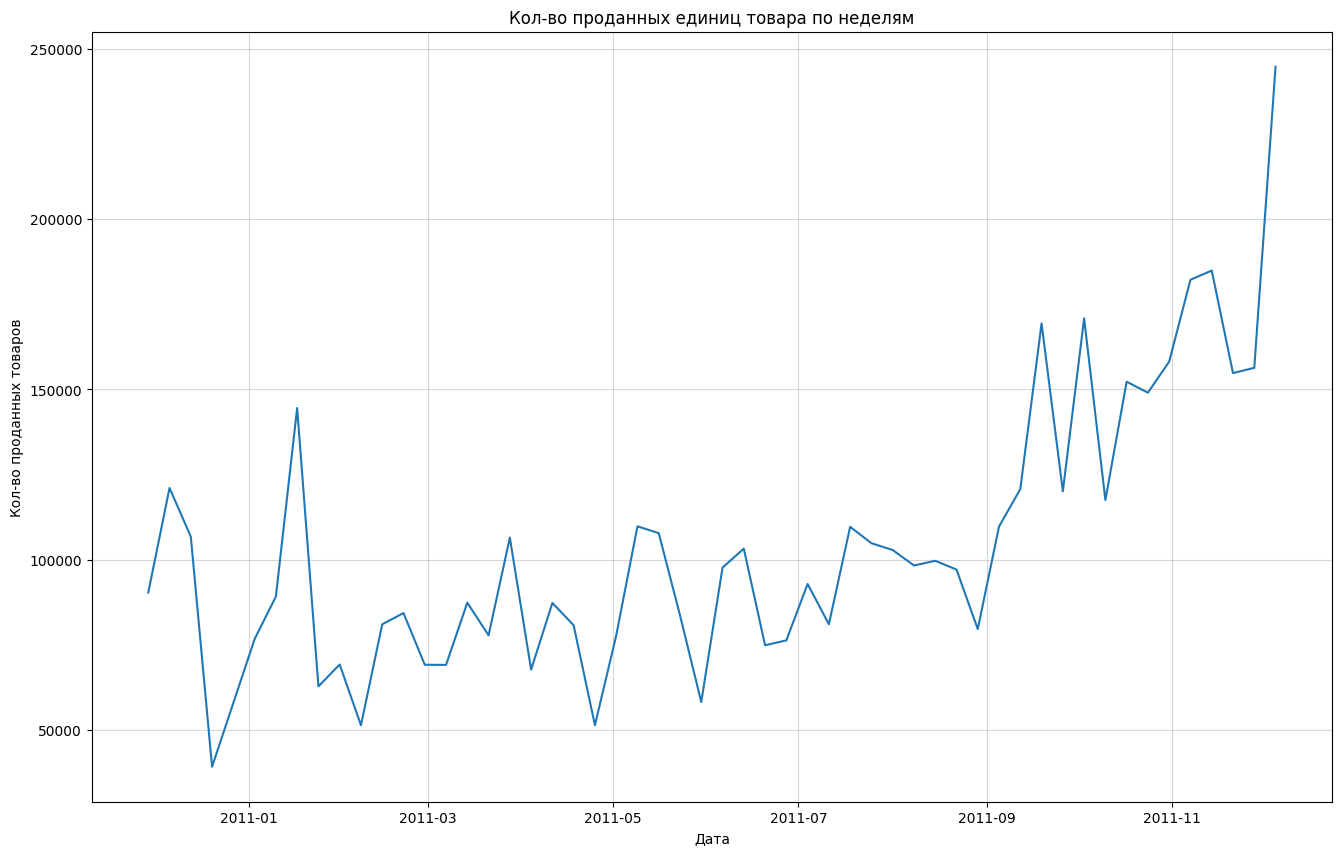

In [181]:
# Линейный график, кол-во проданных единиц по неделям

fig = plt.figure()
fig.set_size_inches(16, 10)
plt.plot(weeks_quantity['week'].dt.start_time, weeks_quantity['Quantity'])
plt.title("Кол-во проданных единиц товара по неделям")
plt.xlabel('Дата')
plt.ylabel('Кол-во проданных товаров')
plt.grid(alpha=0.5)

plt.show()

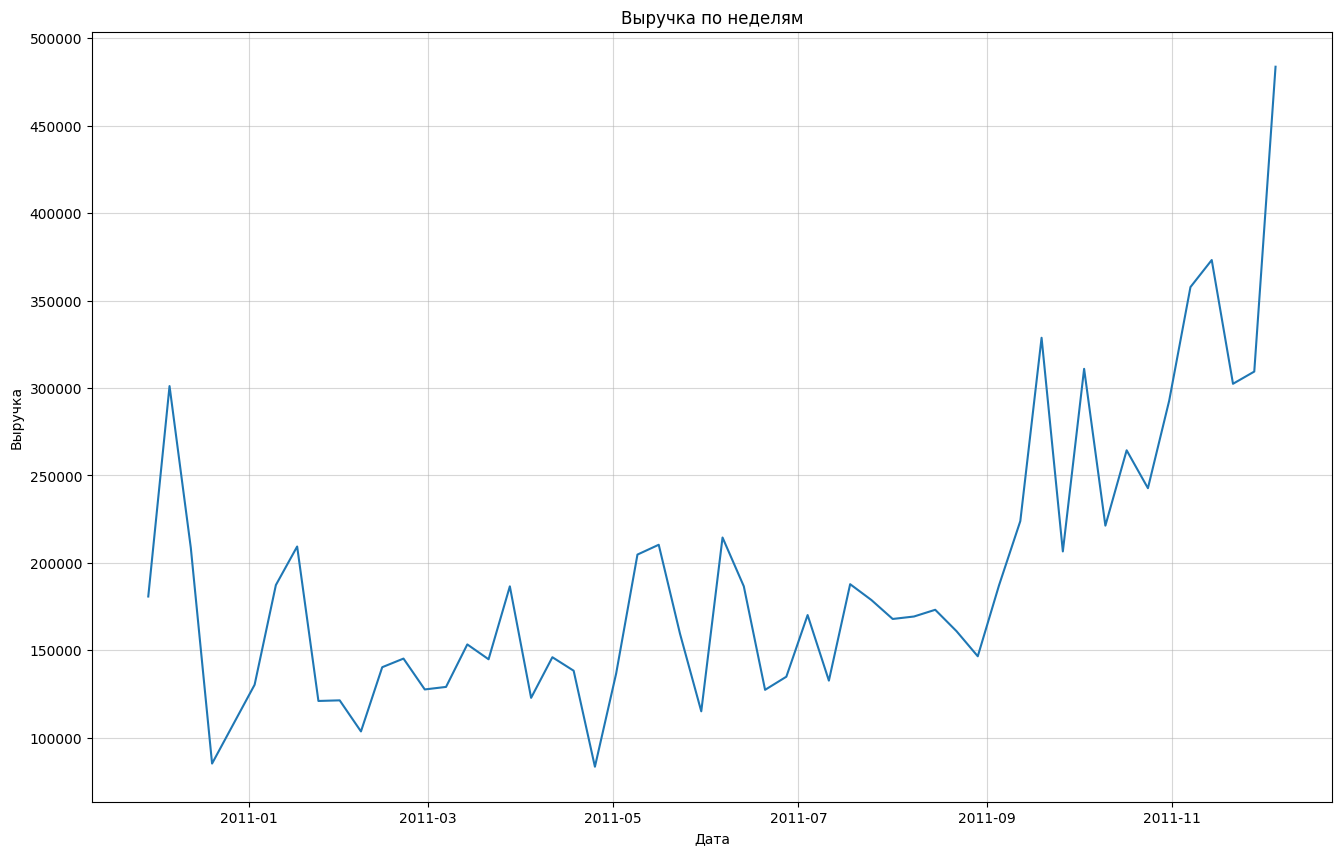

In [197]:
# График выручки по неделям

# создаем колонку выручки
df['revenue'] = df['UnitPrice'] * df['Quantity']

# группируем по неделям
week_revenue = df.groupby('week').agg({'revenue': 'sum'}).reset_index()

# рисуем график
fig = plt.figure()
fig.set_size_inches(16, 10)
plt.plot(week_revenue['week'].dt.start_time, week_revenue['revenue'])
plt.title('Выручка по неделям')
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.grid(alpha=0.5)
plt.show()


In [ ]:
# Создадим колонку которая показывает месяцы

df['month'] = df['InvoiceDate'].dt.to_period('M')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country,week,revenue,month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,United Kingdom,2010-11-29/2010-12-05,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,United Kingdom,2010-11-29/2010-12-05,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,United Kingdom,2010-11-29/2010-12-05,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,United Kingdom,2010-11-29/2010-12-05,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,United Kingdom,2010-11-29/2010-12-05,20.34,2010-12
...,...,...,...,...,...,...,...,...,...,...
522532,581587,22555,PLASTERS IN TIN STRONGMAN,12,2011-12-09 12:50:00,1.65,France,2011-12-05/2011-12-11,19.80,2011-12
522533,581587,22556,PLASTERS IN TIN CIRCUS PARADE,12,2011-12-09 12:50:00,1.65,France,2011-12-05/2011-12-11,19.80,2011-12
522534,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,France,2011-12-05/2011-12-11,16.60,2011-12
522535,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,2011-12-09 12:50:00,3.75,France,2011-12-05/2011-12-11,15.00,2011-12


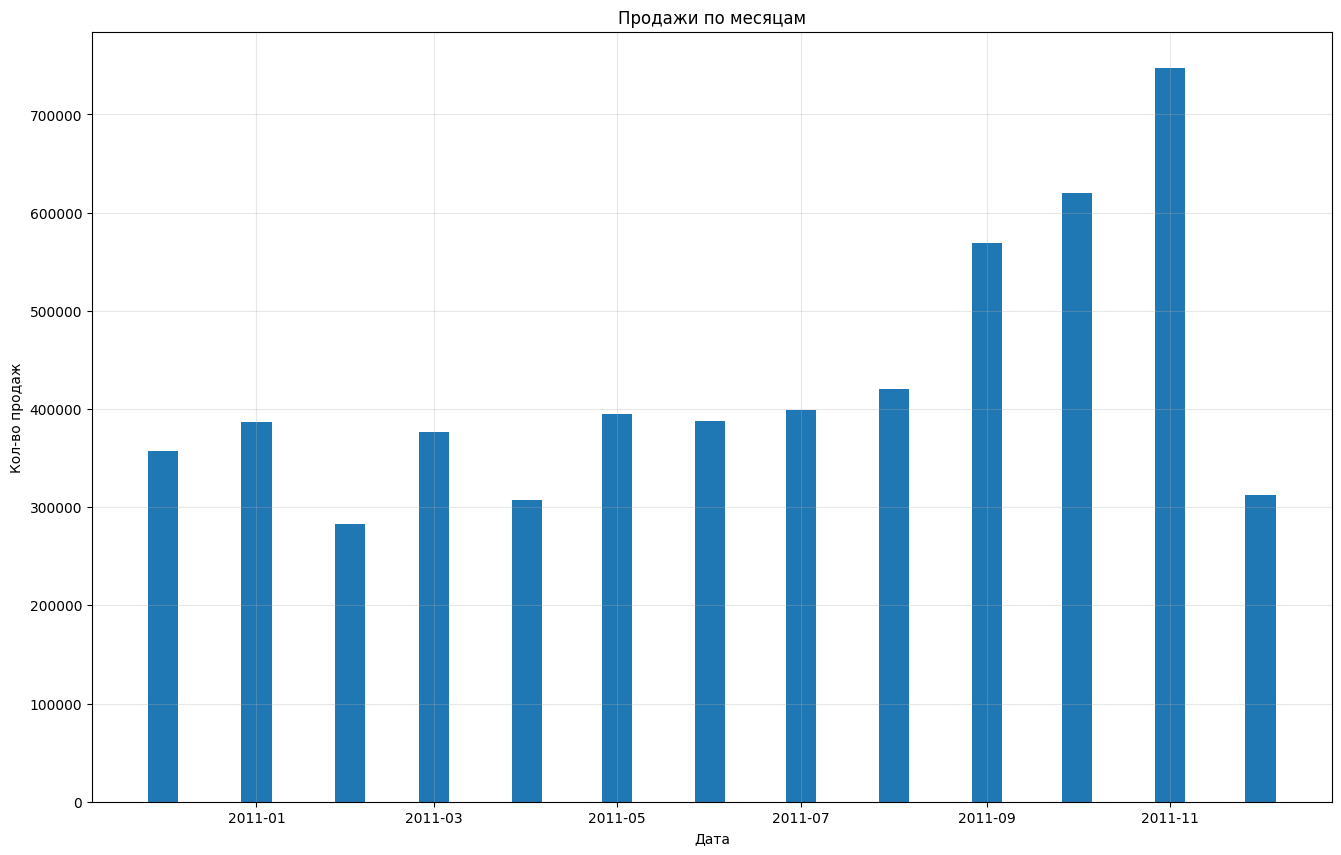

In [207]:
# Рисуем barplot продаж по месяцам 

month_quantity = df.groupby('month').agg({'Quantity': 'sum'}).reset_index()

plt.figure(figsize=(16, 10))
plt.bar(month_quantity['month'].dt.start_time, month_quantity['Quantity'], width=10)
plt.title('Продажи по месяцам')
plt.xlabel('Дата')
plt.ylabel('Кол-во продаж')
plt.grid(alpha=0.3)
plt.show()

<Axes: xlabel='day', ylabel='month'>

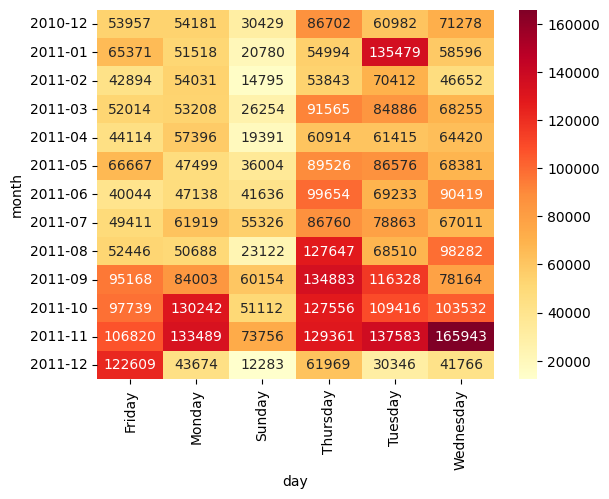

In [241]:
# Рисуем heatmap: месяц × день недели, значение — количество продаж

df['day'] = df['InvoiceDate'].dt.day_name()

day_week = df.groupby(['month', 'day']).agg({'Quantity': 'sum'})

matrix = df.pivot_table(
    index='month',
    columns='day',
    values='Quantity',
    aggfunc='sum'
    )

sns.heatmap(matrix, annot=True, fmt='.0f', cmap='YlOrRd')

## ПОДГОТОВКА ТАБЛИЦЫ ДЛЯ МОДЕЛИ

In [ ]:
# ВЫБИРАЕМ 200–300 САМЫХ ПРОДАВАЕМЫЗХ ТОВАРА.

# Группируем df по паре (StockCode, week) и суммируем Quantity.
# получаем таблицу «сколько единиц каждого товара продано за каждую неделю» —
# это базовая структура для модели: одна строка = один товар в одну неделю.
best_salling = df.groupby(['StockCode', 'week']).agg({'Quantity': 'sum'})

# Для каждого товара считаем, в скольких неделях он вообще продавался.
# получаем Series: индекс — StockCode, значение — кол-во активных недель.
# нужно, чтобы отсеять товары с редкими продажами (1–5 недель за год).
best_week_quantity = best_salling.groupby('StockCode')['Quantity'].size()

# Смотрим статистику
best_week_quantity.describe()

count    3907.000000
mean       25.934733
std        17.343849
min         1.000000
25%        10.000000
50%        25.000000
75%        42.000000
max        53.000000
Name: Quantity, dtype: float64

In [ ]:
# Считаем сколько товаров продавалось в 10...53 неделях

for t in [10, 15, 20, 25, 30, 35, 40, 45, 50, 53]:
    print(t, (best_week_quantity >= t).sum())

# берем 53 недели, так как попадает в нужный диапазон 200-300

10 2966
15 2584
20 2255
25 1962
30 1635
35 1353
40 1094
45 860
50 568
53 288


In [ ]:
# Получили список кодов товаров, которые продавались во все 53 недели года 

top = best_week_quantity[best_week_quantity >= 53].index.tolist()
print(top)

[15036, 20674, 20675, 20676, 20677, 20679, 20685, 20712, 20717, 20718, 20719, 20723, 20724, 20725, 20726, 20727, 20728, 20914, 20970, 20971, 20972, 21034, 21035, 21080, 21086, 21094, 21121, 21135, 21136, 21154, 21155, 21164, 21165, 21174, 21175, 21212, 21213, 21216, 21218, 21231, 21232, 21238, 21239, 21240, 21242, 21259, 21313, 21314, 21326, 21327, 21381, 21385, 21430, 21506, 21507, 21523, 21524, 21533, 21558, 21559, 21623, 21668, 21669, 21670, 21671, 21672, 21673, 21703, 21731, 21733, 21754, 21755, 21756, 21790, 21791, 21843, 21874, 21877, 21888, 21889, 21901, 21907, 21908, 21912, 21915, 21916, 21918, 21928, 21929, 21930, 21931, 21933, 21934, 21935, 21974, 21975, 21976, 21977, 21981, 21982, 21984, 21985, 21990, 22029, 22077, 22079, 22082, 22083, 22090, 22112, 22131, 22139, 22151, 22156, 22161, 22169, 22174, 22178, 22189, 22191, 22193, 22196, 22197, 22212, 22219, 22227, 22273, 22274, 22295, 22297, 22326, 22328, 22333, 22348, 22352, 22355, 22356, 22358, 22367, 22379, 22380, 22381, 22382

In [363]:
# Оставляем только строки, где StockCode входит в список top (те 288 товаров). 
# так из таблицы по всем 3907 товарам остаются только нужные 288.

sw_top = best_salling[best_salling.index.get_level_values('StockCode').isin(top)]
sw_top = sw_top.reset_index()
sw_top

,StockCode,week,Quantity
0,15036,2010-11-29/2010-12-05,75
1,15036,2010-12-06/2010-12-12,21
2,15036,2010-12-13/2010-12-19,35
3,15036,2010-12-20/2010-12-26,30
4,15036,2011-01-03/2011-01-09,18
...,...,...,...
15259,85123A,2011-11-07/2011-11-13,575
15260,85123A,2011-11-14/2011-11-20,1322
15261,85123A,2011-11-21/2011-11-27,897
15262,85123A,2011-11-28/2011-12-04,725


In [369]:
# Проверяем типы колонок

sw_top.dtypes
# все в норме

StockCode           object
week         period[W-SUN]
Quantity             int64
dtype: object

## СОЗДАНИЕ ПРИЗНАКОВ

In [ ]:
# Сортируем sw_top по StockCode и week

sw_top = sw_top.sort_values(['StockCode', 'week']).reset_index(drop=True)
sw_top

,StockCode,week,Quantity
0,15036,2010-11-29/2010-12-05,75
1,15036,2010-12-06/2010-12-12,21
2,15036,2010-12-13/2010-12-19,35
3,15036,2010-12-20/2010-12-26,30
4,15036,2011-01-03/2011-01-09,18
...,...,...,...
15259,85123A,2011-11-07/2011-11-13,575
15260,85123A,2011-11-14/2011-11-20,1322
15261,85123A,2011-11-21/2011-11-27,897
15262,85123A,2011-11-28/2011-12-04,725


In [389]:
# Создаем 4 колонки с лагами — по одной на каждый сдвиг

sw_top['lag_1'] = sw_top.groupby('StockCode')['Quantity'].shift(1)
sw_top['lag_2'] = sw_top.groupby('StockCode')['Quantity'].shift(2)
sw_top['lag_4'] = sw_top.groupby('StockCode')['Quantity'].shift(4)
sw_top['lag_8'] = sw_top.groupby('StockCode')['Quantity'].shift(8)

In [391]:
sw_top.head(20)

,StockCode,week,Quantity,lag_1,lag_2,lag_4,lag_8
0,15036,2010-11-29/2010-12-05,75,NaN,NaN,NaN,NaN
1,15036,2010-12-06/2010-12-12,21,75.0,NaN,NaN,NaN
2,15036,2010-12-13/2010-12-19,35,21.0,75.0,NaN,NaN
3,15036,2010-12-20/2010-12-26,30,35.0,21.0,NaN,NaN
4,15036,2011-01-03/2011-01-09,18,30.0,35.0,75.0,NaN
5,15036,2011-01-10/2011-01-16,159,18.0,30.0,21.0,NaN
6,15036,2011-01-17/2011-01-23,39,159.0,18.0,35.0,NaN
7,15036,2011-01-24/2011-01-30,112,39.0,159.0,30.0,NaN
8,15036,2011-01-31/2011-02-06,1913,112.0,39.0,18.0,75.0
9,15036,2011-02-07/2011-02-13,68,1913.0,112.0,159.0,21.0


In [392]:
# Скользящие средние за 4 и 8 предыдущих недель

# shift(1) отбрасывает текущую неделю, rolling(4) берёт окно из 4 предыдущих
sw_top['roll_mean_4'] = (
    sw_top.groupby('StockCode')['Quantity']
    .transform(lambda x: x.shift(1).rolling(4).mean())
)

sw_top['roll_mean_8'] = (
    sw_top.groupby('StockCode')['Quantity']
    .transform(lambda x: x.shift(1).rolling(8).mean())
)

# Максимум за 4 предыдущие недели
sw_top['roll_max_4'] = (
    sw_top.groupby('StockCode')['Quantity']
    .transform(lambda x: x.shift(1).rolling(4).max())
)

In [396]:
# Создаем номер недели, месяца и квартала из week

sw_top['week_num'] = sw_top['week'].dt.week
sw_top['month_num'] = sw_top['week'].dt.month
sw_top['quarter_num'] = sw_top['week'].dt.quarter

In [399]:
# Количество недель с начала наблюдений.

sw_top['weeks_since_start'] = sw_top['week'].rank(method='dense').astype(int)

In [400]:
sw_top

,StockCode,week,Quantity,lag_1,lag_2,lag_4,lag_8,roll_mean_4,roll_mean_8,roll_max_4,week_num,month_num,quarter_num,weeks_since_start
0,15036,2010-11-29/2010-12-05,75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48,12,4,1
1,15036,2010-12-06/2010-12-12,21,75.0,NaN,NaN,NaN,NaN,NaN,NaN,49,12,4,2
2,15036,2010-12-13/2010-12-19,35,21.0,75.0,NaN,NaN,NaN,NaN,NaN,50,12,4,3
3,15036,2010-12-20/2010-12-26,30,35.0,21.0,NaN,NaN,NaN,NaN,NaN,51,12,4,4
4,15036,2011-01-03/2011-01-09,18,30.0,35.0,75.0,NaN,40.25,NaN,75.0,1,1,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15259,85123A,2011-11-07/2011-11-13,575,1702.0,444.0,679.0,658.0,764.00,622.500,1702.0,45,11,4,49
15260,85123A,2011-11-14/2011-11-20,1322,575.0,1702.0,231.0,705.0,738.00,612.125,1702.0,46,11,4,50
15261,85123A,2011-11-21/2011-11-27,897,1322.0,575.0,444.0,398.0,1010.75,689.250,1702.0,47,11,4,51
15262,85123A,2011-11-28/2011-12-04,725,897.0,1322.0,1702.0,163.0,1124.00,751.625,1702.0,48,12,4,52


## РАЗДЕЛЕНИЕ ДАННЫХ

In [ ]:
# Делим данные на train 70%, valid 15%, test 15%

train = sw_top[sw_top['week'] < '2011-09-01']
valid = sw_top[(sw_top['week'] >= '2011-09-01') & (sw_top['week'] < '2011-11-01')]
test = sw_top[sw_top['week'] >= '2011-11-01']

len(train), len(valid), len(test)
# хорошее разделение

(10944, 2592, 1728)

In [438]:
# Делим данные на X и Y и удялем week

# делим train
X_train = train.drop('Quantity', axis=1)
Y_train = train['Quantity']
# удаляем week так как она не нужна
X_train = X_train.drop('week', axis=1)

# делим valid
X_valid = valid.drop('Quantity', axis=1)
Y_valid = valid['Quantity']
# удаляем week так как она не нужна
X_valid = X_valid.drop('week', axis=1)

# делим test
X_test = test.drop('Quantity', axis=1)
Y_test = test['Quantity']
# удаляем week так как она не нужна
X_test = X_test.drop('week', axis=1)

## БАЗЛАЙНЫ

In [440]:
# Базлайн 1 - прогноз на след. неделю = продажи прошлой недели
baseline_1 = X_valid['lag_1']

# Базлайн 2 - прогноз = среднее за 4 недели
baseline_2 = X_valid['roll_mean_4']

In [470]:
# Считаем MAE, RMSE, WAPE - это точка сравнения для CatBoost

# считаем с baseline_1
baseline_1_mae = abs(baseline_1 - Y_valid).mean()
baseline_1_rmse = (((baseline_1 - Y_valid)**2).mean())**(1/2)
baseline_1_wape = (abs(baseline_1 - Y_valid).sum() / Y_valid.sum()) * 100

print(f'MAE baseline_1 = {baseline_1_mae.round(2)}')
print(f'RMSE baseline_1 = {baseline_1_rmse.round(2)}')
print(f'WAPE baseline_1 = {baseline_1_wape.round(2)}%')

print('- - - - - - - - - - - - -')

# считаем с baseline_2
baseline_2_mae = abs(baseline_2 - Y_valid).mean()
baseline_2_rmse = (((baseline_2 - Y_valid)**2).mean())**(1/2)
baseline_2_wape = (abs(baseline_2 - Y_valid).sum() / Y_valid.sum()) * 100

print(f'MAE baseline_2 = {baseline_2_mae.round(2)}')
print(f'RMSE baseline_2 = {baseline_2_rmse.round(2)}')
print(f'WAPE baseline_2 = {baseline_2_wape.round(2)}%')

MAE baseline_1 = 94.52
RMSE baseline_1 = 202.74
WAPE baseline_1 = 71.74%
- - - - - - - - - - - - -
MAE baseline_2 = 78.95
RMSE baseline_2 = 167.69
WAPE baseline_2 = 59.93%


## ОБУЧЕНИЕ МОДЕЛИ CATBOOST REGRESSOR

In [531]:
# Обучаем модель на трейне

from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=10000,
    depth=8,
    learning_rate=0.02,
    verbose=0,
    random_seed=42,
    loss_function='MAE'
    )

model.fit(
    X_train, Y_train,
    cat_features=['StockCode'],
    eval_set=(X_valid, Y_valid),
    early_stopping_rounds=50,
    verbose=100,
)

preds = model.predict(X_valid)

0:	learn: 90.4065688	test: 101.0560098	best: 101.0560098 (0)	total: 5.43ms	remaining: 54.3s
100:	learn: 66.1912644	test: 72.2785388	best: 72.2785388 (100)	total: 317ms	remaining: 31.1s
200:	learn: 62.6346032	test: 70.2410565	best: 70.2410565 (200)	total: 631ms	remaining: 30.7s
300:	learn: 60.5771140	test: 69.8559178	best: 69.8547307 (298)	total: 935ms	remaining: 30.1s
400:	learn: 58.9889548	test: 69.7519248	best: 69.7019686 (388)	total: 1.24s	remaining: 29.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 69.70196861
bestIteration = 388

Shrink model to first 389 iterations.


In [532]:
# Оцениваем качество модели

model_mae = abs(preds - Y_valid).mean()
model_rmse = (((preds - Y_valid)**2).mean())**(1/2)
model_wape = (abs(preds - Y_valid).sum() / Y_valid.sum()) * 100

print(f'MAE valid = {model_mae.round(2)}')
print(f'RMSE valid = {model_rmse.round(2)}')
print(f'WAPE valid = {model_wape.round(2)}%')

MAE valid = 69.7
RMSE valid = 163.91
WAPE valid = 52.91%


In [533]:
# Обучаем на тестовой выборке

test_preds = model.predict(X_test)

test_mae  = abs(test_preds - Y_test).mean()
test_rmse = (((test_preds - Y_test) ** 2).mean()) ** 0.5
test_wape = (abs(test_preds - Y_test).sum() / Y_test.sum()) * 100

print(f'MAE test = {test_mae.round(2)}')
print(f'RMSE test = {test_rmse.round(2)}')
print(f'WAPE test = {test_wape.round(2)}%')

MAE test = 82.75
RMSE test = 226.76
WAPE test = 53.66%


## АНАЛИЗ РЕЗУЛЬТАТА

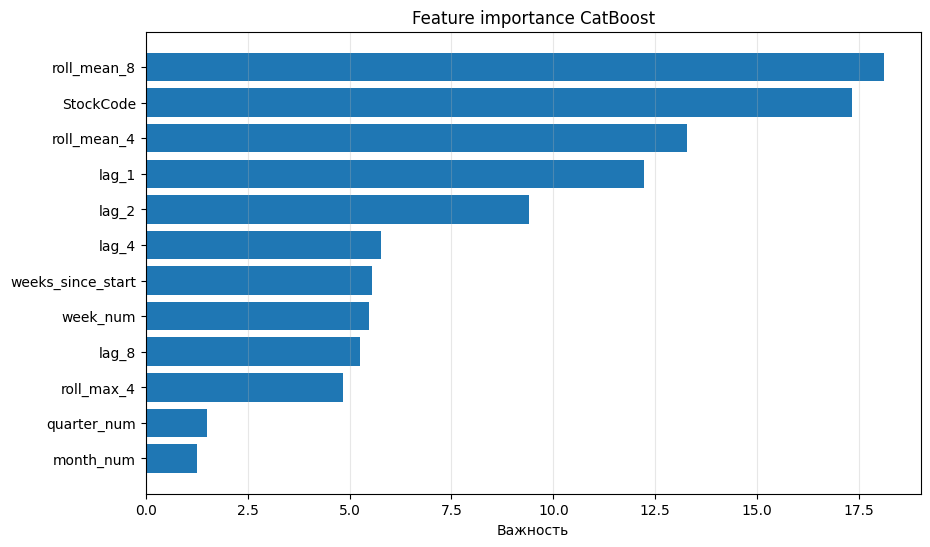

              feature  importance
6         roll_mean_8   18.108536
0           StockCode   17.321495
5         roll_mean_4   13.267947
1               lag_1   12.228444
2               lag_2    9.399381
3               lag_4    5.783865
11  weeks_since_start    5.555819
8            week_num    5.466679
4               lag_8    5.245408
7          roll_max_4    4.847444
10        quarter_num    1.511236
9           month_num    1.263745


In [511]:
# График важности признаков

importance = model.get_feature_importance()
feature_names = X_train.columns

fi = pd.DataFrame({
    'feature': feature_names,
    'importance': importance,
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(fi['feature'], fi['importance'])
plt.xlabel('Важность')
plt.title('Feature importance CatBoost')
plt.grid(axis='x', alpha=0.3)
plt.show()

print(fi.sort_values('importance', ascending=False))

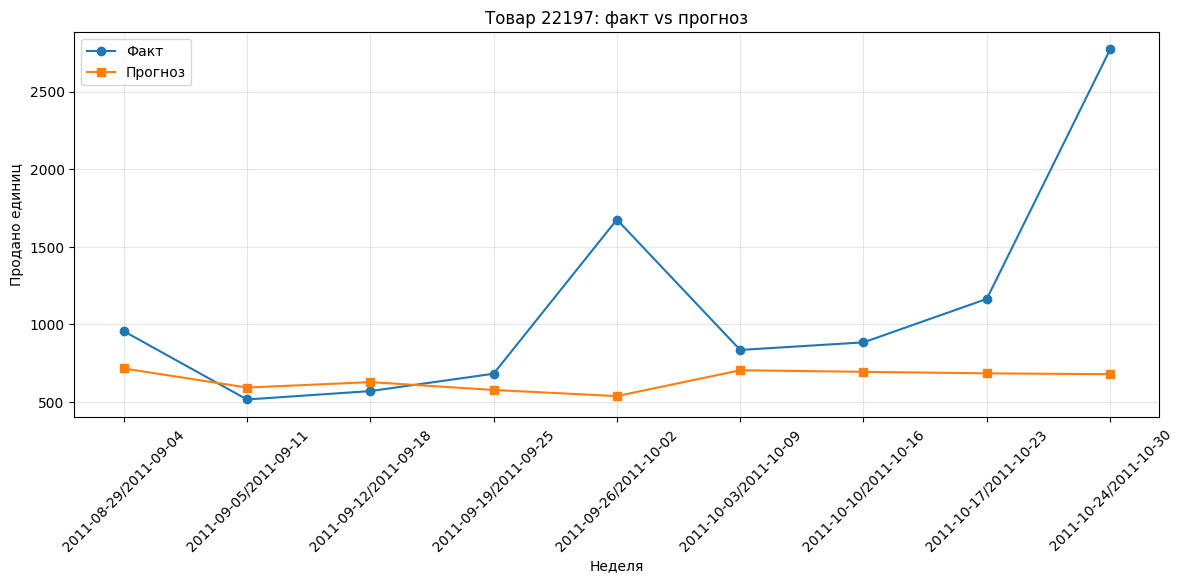

In [518]:
# Сравнение предсказание и факта

# Берём один товар (например, самый продаваемый в valid)
top_code = (valid.groupby('StockCode')['Quantity']
            .sum()
            .sort_values(ascending=False)
            .index[0])

# Собираем предсказания в valid
valid_analysis = valid.copy()
valid_analysis['pred'] = preds

# Один товар, два ряда: факт и прогноз
sub = valid_analysis[valid_analysis['StockCode'] == top_code].sort_values('week')

plt.figure(figsize=(14, 5))
plt.plot(sub['week'].astype(str), sub['Quantity'], marker='o', label='Факт')
plt.plot(sub['week'].astype(str), sub['pred'], marker='s', label='Прогноз')
plt.title(f'Товар {top_code}: факт vs прогноз')
plt.xlabel('Неделя')
plt.ylabel('Продано единиц')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.show()

In [535]:
# Финальная таблица сравнения всех моделей

results = pd.DataFrame({
    'Модель': [
        'Baseline 1 (lag_1)',
        'Baseline 2 (roll_mean_4)',
        'CatBoost (valid)',
        'CatBoost (test)',
    ],
    'MAE':  [94.52, 78.95, 69.70, 82.75],
    'RMSE': [202.74, 167.69, 163.91, 226.76],
    'WAPE %': [71.74, 59.93, 52.91, 53.66],
})

print(results.to_string(index=False))

                  Модель   MAE   RMSE  WAPE %
      Baseline 1 (lag_1) 94.52 202.74   71.74
Baseline 2 (roll_mean_4) 78.95 167.69   59.93
        CatBoost (valid) 69.70 163.91   52.91
         CatBoost (test) 82.75 226.76   53.66


## Итоговые выводы

### Что было сделано

Построен полный пайплайн прогноза недельного спроса на товары:
1. Очистка данных: удалены отмены, возвраты, нулевые/отрицательные Quantity и UnitPrice, полные дубликаты, служебные позиции (postage, fee, manual, gift-сертификаты). Итог — 524 878 строк.
2. EDA: проанализированы распределения Quantity и UnitPrice, сезонность по неделям и месяцам, активность по дням недели, топ товаров и стран.
3. Подготовка таблицы: отобраны 288 товаров, продававшихся все 53 недели года, агрегированы до уровня StockCode + week.
4. Признаки: лаги 1/2/4/8 недель, скользящие средние за 4 и 8 недель, максимум за 4 недели, календарные признаки.
5. Разделение по времени: train (до сентября), valid (сентябрь–октябрь), test (ноябрь–декабрь) — без перемешивания.
6. Модели: два бейзлайна и CatBoostRegressor с `loss_function='MAE'`.

### Итоговые метрики

| Модель | MAE | RMSE | WAPE % |
|---|---|---|---|
| Baseline 1 (lag_1) | 94.52 | 202.74 | 71.74 |
| Baseline 2 (roll_mean_4) | 78.95 | 167.69 | 59.93 |
| CatBoost (valid) | 69.70 | 163.91 | 52.91 |
| CatBoost (test) | 82.75 | 226.76 | 53.66 |

CatBoost бьёт оба бейзлайна на valid и test по всем трём метрикам. На тесте WAPE остаётся практически на уровне валидации (52.91% → 53.66%), что говорит об устойчивости модели к новым данным, несмотря на то что тестовый период — сезонный пик (ноябрь–декабрь).

### Важность признаков

Топ-5 признаков по важности:
1. `roll_mean_8` (среднее за 8 недель) — долгосрочный тренд товара
2. `StockCode` — индивидуальный уровень спроса товара
3. `roll_mean_4` — среднесрочный тренд
4. `lag_1` — прошлая неделя
5. `lag_2` — две недели назад

Модель опирается на сглаженные тренды и индивидуальность товара, а не на отдельные выбросы. Календарные признаки (`month_num`, `quarter_num`) вносят небольшой вклад, потому что в данных всего один годовой сезон.

### Где модель ошибается

- **Сезонный пик**: RMSE на test выше, чем на valid — значит, есть отдельные крупные промахи в декабре. Модель не может точно предсказать резкие всплески продаж перед Рождеством.
- **Крупные товары**: график «факт vs прогноз» показывает, что модель занижает прогноз для товаров с большим объёмом продаж, если у них были всплески в прошлом.

### Идеи для v2

- Добавить признаки «недель до Рождества», волатильность (`roll_std`), тренд (`roll_mean_4 − roll_mean_8`).
- Обучить отдельную модель только на UK или для товаров-лидеров.
- Использовать `TimeSeriesSplit` для более честного подбора гиперпараметров.
- Проверить логарифмирование таргета для устойчивости к выбросам.
- Добавить страны как признак (уровень StockCode + Country + week).

### Итог

Модель пригодна для базового планирования закупок по 288 стабильным товарам. Для критичных решений (крупные оптовые заказы, рождественский пик) прогноз стоит использовать как ориентир, а не как точный план.